# CNN Murni Klasifikasi Tingkat Kematangan Pisang

Notebook ini adalah versi final yang langsung membaca folder dataset dari Google Drive tanpa ekstrak ZIP.

Path dataset yang digunakan sesuai struktur Google Drive kamu:

```text
/content/drive/MyDrive/Tugas_Besar_Asli/banana_dataset/
├── Green/
├── Semi-ripe/
├── Ripe/
└── Overripe/
```

Fokus model:
- CNN murni/custom, bukan MobileNetV2.
- Tidak menggunakan data augmentation pada model utama.
- Epoch 100.
- Kernel Conv2D 3x3.
- Stride 1.
- Padding `same`.
- Aktivasi ReLU.
- Optimizer AdamW.
- Evaluasi lengkap: accuracy, loss, confusion matrix, classification report, grafik, dan uji foto pisang sendiri.


## 1. Import library

In [6]:
import os
import json
import random
import shutil
import hashlib
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image

import tensorflow as tf
from tensorflow.keras import layers, models, regularizers

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

print("TensorFlow version:", tf.__version__)
print("GPU tersedia:", tf.config.list_physical_devices('GPU'))

TensorFlow version: 2.20.0
GPU tersedia: []


## 2. Konfigurasi utama

Bagian ini adalah ringkasan parameter yang bisa dimasukkan ke laporan atau PPT.

In [7]:
# =========================
# MOUNT GOOGLE DRIVE
# =========================
# Jalankan cell ini dulu. Jika muncul permintaan izin, pilih Allow/Izinkan.
try:
    from google.colab import drive
    drive.mount('/content/drive')
    print("Google Drive berhasil di-mount.")
except Exception as e:
    print("Info: Drive tidak di-mount otomatis. Jika tidak di Google Colab, abaikan pesan ini.")
    print(e)

# =========================
# KONFIGURASI DATASET
# =========================
# Path sesuai urutan folder di Google Drive kamu:
# My Drive > Tugas_Besar_Asli > banana_dataset
DATA_DIR = "/content/drive/MyDrive/Tugas_Besar_Asli/banana_dataset"

# =========================
# KONFIGURASI MODEL CNN
# =========================
IMG_SIZE = 128
BATCH_SIZE = 32
EPOCHS = 100
SEED = 42

LEARNING_RATE = 0.0008
WEIGHT_DECAY = 0.0001
FINAL_DROPOUT = 0.50

# Urutan kelas yang diinginkan agar laporan rapi.
PREFERRED_CLASS_ORDER = ["Green", "Semi-ripe", "Ripe", "Overripe"]

# Folder output hasil training.
# Disimpan di Drive agar tidak hilang setelah runtime Colab selesai.
OUTPUT_DIR = "/content/drive/MyDrive/Tugas_Besar_Asli/hasil_cnn_pisang"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Reproducibility
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

config_summary = {
    "Data directory": DATA_DIR,
    "Output directory": OUTPUT_DIR,
    "Image size": f"{IMG_SIZE} x {IMG_SIZE}",
    "Batch size": BATCH_SIZE,
    "Epoch": EPOCHS,
    "Model": "CNN murni/custom",
    "Augmentation": "Tidak digunakan pada model utama",
    "Kernel Conv2D": "3 x 3",
    "Stride Conv2D": 1,
    "Padding Conv2D": "same",
    "Activation": "ReLU",
    "Pooling": "MaxPooling2D 2 x 2",
    "Feature vector": "GlobalAveragePooling2D",
    "Optimizer": "AdamW jika tersedia; fallback Adam",
    "Learning rate": LEARNING_RATE,
    "Weight decay": WEIGHT_DECAY,
    "Dropout akhir": FINAL_DROPOUT,
    "Checkpoint": "best model berdasarkan val_loss",
    "Loss": "sparse_categorical_crossentropy",
    "Metric": "accuracy"
}

pd.DataFrame(list(config_summary.items()), columns=["Parameter", "Nilai"])


Info: Drive tidak di-mount otomatis. Jika tidak di Google Colab, abaikan pesan ini.
Mountpoint must not already contain files


,Parameter,Nilai
0,Data directory,/content/drive/MyDrive/Tugas_Besar_Asli/banana...
1,Output directory,/content/drive/MyDrive/Tugas_Besar_Asli/hasil_...
2,Image size,128 x 128
3,Batch size,32
4,Epoch,100
5,Model,CNN murni/custom
6,Augmentation,Tidak digunakan pada model utama
7,Kernel Conv2D,3 x 3
8,Stride Conv2D,1
9,Padding Conv2D,same


## 3. Cek folder dataset

Kode ini memastikan folder `banana_dataset` sudah terbaca dari Google Drive.

Urutan folder sesuai screenshot kamu:

```text
My Drive > Tugas_Besar_Asli > banana_dataset
```

Path Colab yang benar:

```python
/content/drive/MyDrive/Tugas_Besar_Asli/banana_dataset
```


In [13]:
# ============================================================
# CEK FOLDER DATASET SESUAI STRUKTUR DRIVE
# ============================================================

from pathlib import Path
import json
import os

def has_class_folders(path):
    """Cek apakah sebuah folder berisi folder kelas dataset."""
    if not Path(path).exists():
        return False
    subfolders = [p.name for p in Path(path).iterdir() if p.is_dir() and not p.name.startswith(".")]
    return len(set(PREFERRED_CLASS_ORDER).intersection(set(subfolders))) >= 2

# Path utama sesuai screenshot Google Drive:
# My Drive > Tugas_Besar_Asli > banana_dataset
main_candidate = Path(DATA_DIR)

# Beberapa kandidat cadangan jika nama folder typo atau dataset ada di /content
candidate_paths = [
    Path("/content/drive/MyDrive/Tugas_Besar_Asli/banana_dataset"),
    Path("/content/drive/MyDrive/Tugas_Besar_Asli/banana_dataset"),
    Path("/content/banana_dataset"),
    main_candidate
]

# Hilangkan duplikasi kandidat
unique_candidates = []
for p in candidate_paths:
    if p not in unique_candidates:
        unique_candidates.append(p)

data_path = None

for candidate in unique_candidates:
    if candidate.exists() and has_class_folders(candidate):
        data_path = candidate
        break



# ============================================================
# CEK FOLDER KELAS
# ============================================================

class_folders = [
    p for p in data_path.iterdir()
    if p.is_dir() and not p.name.startswith(".")
]

if len(class_folders) == 0:
    print("Isi folder dataset:")
    print(list(data_path.iterdir()))
    raise ValueError(
        f"Tidak ada folder kelas di dalam {DATA_DIR}. "
        "Pastikan struktur foldernya seperti banana_dataset/Green, banana_dataset/Ripe, dst."
    )

found_classes = [p.name for p in class_folders]

# Gunakan urutan kelas yang diinginkan jika semua kelas tersedia.
if set(PREFERRED_CLASS_ORDER).issubset(set(found_classes)):
    CLASS_NAMES = PREFERRED_CLASS_ORDER
else:
    CLASS_NAMES = sorted(found_classes)

class_to_id = {name: idx for idx, name in enumerate(CLASS_NAMES)}
id_to_class = {idx: name for name, idx in class_to_id.items()}

print("\nFolder kelas ditemukan:", found_classes)
print("Urutan kelas yang digunakan:", CLASS_NAMES)
print("Mapping label:", class_to_id)

# Cek jumlah gambar per kelas
IMAGE_EXTENSIONS = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}
total_images = 0
print("\nJumlah gambar per kelas:")
for class_name in CLASS_NAMES:
    class_dir = data_path / class_name
    if not class_dir.exists():
        print(f"{class_name}: folder tidak ditemukan")
        continue
    image_files = [f for f in class_dir.iterdir() if f.suffix.lower() in IMAGE_EXTENSIONS]
    total_images += len(image_files)
    print(f"{class_name}: {len(image_files)} gambar")

print("Total gambar:", total_images)

if total_images == 0:
    raise ValueError("Tidak ada gambar yang terbaca. Pastikan gambar berada langsung di dalam folder kelas.")

with open(os.path.join(OUTPUT_DIR, "class_indices.json"), "w") as f:
    json.dump(class_to_id, f, indent=4)

print("\nclass_indices.json berhasil disimpan di:")
print(os.path.join(OUTPUT_DIR, "class_indices.json"))


AttributeError: 'NoneType' object has no attribute 'iterdir'

## 4. Membaca gambar, validasi file, dan membersihkan duplikat konflik label

Tahap ini tidak mengubah folder asli. Kode hanya membuat daftar file gambar yang bersih untuk training.

In [ ]:
valid_exts = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

records = []
corrupt_files = []

def file_hash(path):
    h = hashlib.md5()
    with open(path, "rb") as f:
        for chunk in iter(lambda: f.read(8192), b""):
            h.update(chunk)
    return h.hexdigest()

for class_name in CLASS_NAMES:
    folder = data_path / class_name
    if not folder.exists():
        print(f"Peringatan: folder kelas tidak ditemukan: {folder}")
        continue

    for img_path in folder.rglob("*"):
        if img_path.suffix.lower() not in valid_exts:
            continue

        try:
            with Image.open(img_path) as img:
                img.verify()
            h = file_hash(img_path)
            records.append({
                "path": str(img_path),
                "label_name": class_name,
                "label": class_to_id[class_name],
                "hash": h
            })
        except Exception as e:
            corrupt_files.append((str(img_path), str(e)))

df = pd.DataFrame(records)

print("Total gambar terbaca:", len(df))
print("Total gambar rusak:", len(corrupt_files))

if len(corrupt_files) > 0:
    print("Contoh file rusak:")
    for item in corrupt_files[:5]:
        print(item)

# Deteksi hash yang muncul di lebih dari satu label
hash_label_count = df.groupby("hash")["label_name"].nunique()
conflict_hashes = set(hash_label_count[hash_label_count > 1].index)

print("Jumlah hash konflik label:", len(conflict_hashes))

if len(conflict_hashes) > 0:
    conflict_df = df[df["hash"].isin(conflict_hashes)].sort_values("hash")
    display(conflict_df[["path", "label_name", "hash"]])

# Bersihkan duplikat:
# - jika ada duplikat sama persis, simpan satu file saja
# - jika ada duplikat konflik label, kode ini tetap hanya menyimpan kemunculan pertama
df_clean = df.sort_values(["hash", "path"]).drop_duplicates(subset=["hash"], keep="first").reset_index(drop=True)

print("Total gambar setelah pembersihan duplikat:", len(df_clean))

dist = df_clean["label_name"].value_counts().reindex(CLASS_NAMES)
display(pd.DataFrame({
    "Kelas": dist.index,
    "Jumlah gambar": dist.values,
    "Persentase": (dist.values / len(df_clean) * 100).round(2)
}))

df_clean.to_csv(os.path.join(OUTPUT_DIR, "dataset_clean.csv"), index=False)

Total gambar terbaca: 820
Total gambar rusak: 0
Jumlah hash konflik label: 1


,path,label_name,hash
332,/content/drive/MyDrive/Tugas_Besar_Asli/banana...,Semi-ripe,f272af58bb66ff5f7fada00105a576de
503,/content/drive/MyDrive/Tugas_Besar_Asli/banana...,Ripe,f272af58bb66ff5f7fada00105a576de


Total gambar setelah pembersihan duplikat: 819


,Kelas,Jumlah gambar,Persentase
0,Green,212,25.89
1,Semi-ripe,203,24.79
2,Ripe,201,24.54
3,Overripe,203,24.79


## 5. Split dataset menjadi train, validation, dan test

Pembagian:
- Training 70%
- Validation 15%
- Test 15%

In [ ]:
train_df, temp_df = train_test_split(
    df_clean,
    test_size=0.30,
    stratify=df_clean["label"],
    random_state=SEED
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    stratify=temp_df["label"],
    random_state=SEED
)

train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

print("Jumlah train:", len(train_df))
print("Jumlah validation:", len(val_df))
print("Jumlah test:", len(test_df))

def split_distribution(name, split_df):
    vc = split_df["label_name"].value_counts().reindex(CLASS_NAMES)
    return pd.DataFrame({
        "Split": name,
        "Kelas": vc.index,
        "Jumlah": vc.values
    })

split_dist = pd.concat([
    split_distribution("Train", train_df),
    split_distribution("Validation", val_df),
    split_distribution("Test", test_df)
], ignore_index=True)

display(split_dist)

train_df.to_csv(os.path.join(OUTPUT_DIR, "train_split.csv"), index=False)
val_df.to_csv(os.path.join(OUTPUT_DIR, "validation_split.csv"), index=False)
test_df.to_csv(os.path.join(OUTPUT_DIR, "test_split.csv"), index=False)

Jumlah train: 573
Jumlah validation: 123
Jumlah test: 123


,Split,Kelas,Jumlah
0,Train,Green,148
1,Train,Semi-ripe,142
2,Train,Ripe,141
3,Train,Overripe,142
4,Validation,Green,32
5,Validation,Semi-ripe,30
6,Validation,Ripe,30
7,Validation,Overripe,31
8,Test,Green,32
9,Test,Semi-ripe,31


## 6. Visualisasi contoh gambar

Gunakan bagian ini untuk memastikan data sudah terbaca dengan benar.

/tmp/ipykernel_4100/3491159250.py:3: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  sample_df = df_clean.groupby("label_name", group_keys=False).apply(


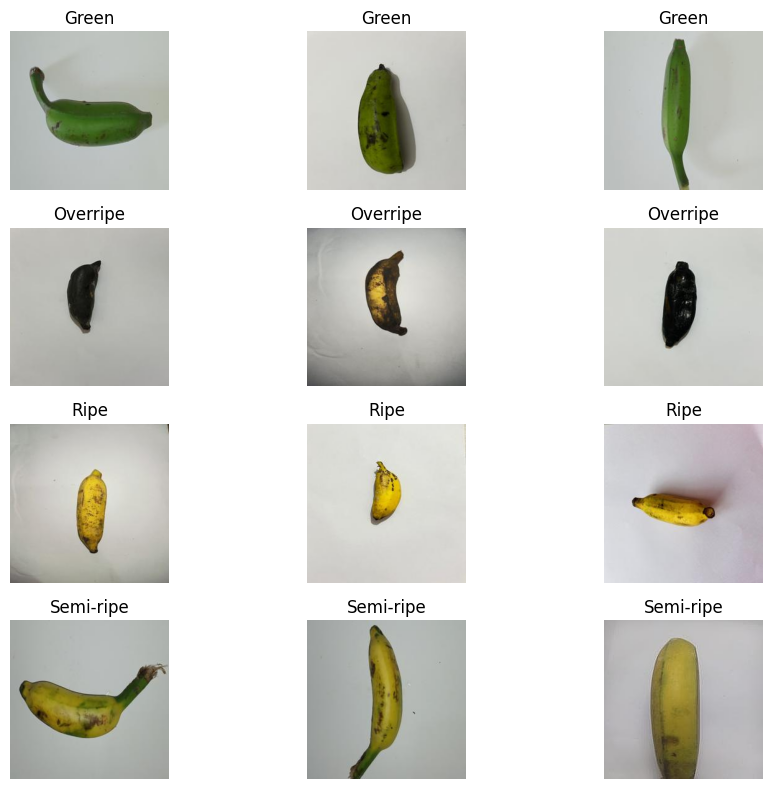

In [ ]:
plt.figure(figsize=(10, 8))

sample_df = df_clean.groupby("label_name", group_keys=False).apply(
    lambda x: x.sample(min(3, len(x)), random_state=SEED)
).reset_index(drop=True)

for i, row in sample_df.iterrows():
    img = Image.open(row["path"]).convert("RGB")
    plt.subplot(len(CLASS_NAMES), 3, i + 1)
    plt.imshow(img)
    plt.title(row["label_name"])
    plt.axis("off")

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "contoh_gambar_dataset.png"), dpi=200)
plt.show()

## 7. Membuat pipeline `tf.data`

Pipeline ini membaca gambar dari path, resize menjadi 128x128, lalu membuat batch.

Normalisasi piksel dilakukan di dalam model menggunakan `Rescaling(1./255)`, jadi tidak ada normalisasi ganda.

In [ ]:
AUTOTUNE = tf.data.AUTOTUNE

def load_image(path, label):
    img = tf.io.read_file(path)
    img = tf.image.decode_image(img, channels=3, expand_animations=False)
    img = tf.image.resize(img, [IMG_SIZE, IMG_SIZE])
    img = tf.cast(img, tf.float32)
    return img, label

def make_dataset(split_df, shuffle=False):
    paths = split_df["path"].values
    labels = split_df["label"].values.astype(np.int32)

    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    ds = ds.map(load_image, num_parallel_calls=AUTOTUNE)

    if shuffle:
        ds = ds.shuffle(buffer_size=len(split_df), seed=SEED, reshuffle_each_iteration=True)

    ds = ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)
    return ds

train_ds = make_dataset(train_df, shuffle=True)
val_ds = make_dataset(val_df, shuffle=False)
test_ds = make_dataset(test_df, shuffle=False)

for images, labels in train_ds.take(1):
    print("Bentuk batch gambar:", images.shape)
    print("Bentuk batch label:", labels.shape)
    print("Rentang piksel sebelum masuk Rescaling model:", float(tf.reduce_min(images)), "sampai", float(tf.reduce_max(images)))

Bentuk batch gambar: (32, 128, 128, 3)
Bentuk batch label: (32,)
Rentang piksel sebelum masuk Rescaling model: 0.0 sampai 255.0


## 8. Membuat model CNN murni/custom

Konfigurasi utama:
- Kernel 3x3
- Stride 1
- Padding same
- Aktivasi ReLU
- MaxPooling 2x2
- GlobalAveragePooling2D
- Dense softmax 4 kelas

In [ ]:
NUM_CLASSES = len(CLASS_NAMES)

def conv_block(x, filters, dropout_rate):
    x = layers.Conv2D(
        filters=filters,
        kernel_size=(3, 3),
        strides=(1, 1),
        padding="same",
        use_bias=False,
        kernel_regularizer=regularizers.l2(WEIGHT_DECAY)
    )(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    x = layers.MaxPooling2D(pool_size=(2, 2))(x)
    x = layers.Dropout(dropout_rate)(x)
    return x

inputs = layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3), name="input_citra_pisang")

# Normalisasi piksel 0-255 menjadi 0-1 dilakukan di dalam model
x = layers.Rescaling(1./255, name="normalisasi_0_1")(inputs)

# Blok ekstraksi fitur CNN
x = conv_block(x, filters=32, dropout_rate=0.10)
x = conv_block(x, filters=64, dropout_rate=0.15)
x = conv_block(x, filters=128, dropout_rate=0.20)

# Feature map akhir diringkas menjadi vektor fitur
x = layers.GlobalAveragePooling2D(name="vektor_fitur_128_dimensi")(x)

# Lapisan klasifikasi
x = layers.Dense(
    64,
    activation="relu",
    kernel_regularizer=regularizers.l2(WEIGHT_DECAY),
    name="dense_64"
)(x)
x = layers.Dropout(FINAL_DROPOUT, name="dropout_akhir")(x)

outputs = layers.Dense(NUM_CLASSES, activation="softmax", name="output_softmax_4_kelas")(x)

cnn_model = models.Model(inputs=inputs, outputs=outputs, name="CNN_Murni_Kematangan_Pisang")

cnn_model.summary()

# Simpan summary model ke file txt
with open(os.path.join(OUTPUT_DIR, "model_summary.txt"), "w", encoding="utf-8") as f:
    cnn_model.summary(print_fn=lambda line: f.write(line + "\n"))

Model: "CNN_Murni_Kematangan_Pisang"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_citra_pisang (InputLayer) │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ normalisasi_0_1 (Rescaling)     │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 128, 128, 32)   │           864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_3 (ReLU)                  │ (None, 128, 128, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 64, 64, 64)     │        18,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_4 (ReLU)                  │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 32, 32, 128)    │        73,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_5 (ReLU)                  │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ vektor_fitur_128_dimensi        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_64 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_akhir (Dropout)         │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_softmax_4_kelas (Dense)  │ (None, 4)              │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 102,436 (400.14 KB)

 Trainable params: 101,988 (398.39 KB)

 Non-trainable params: 448 (1.75 KB)

## 9. Compile model

Compile menentukan aturan training:
- Optimizer: AdamW
- Loss: sparse categorical crossentropy
- Metric: accuracy

In [ ]:
try:
    optimizer = tf.keras.optimizers.AdamW(
        learning_rate=LEARNING_RATE,
        weight_decay=WEIGHT_DECAY
    )
    optimizer_name = "AdamW"
except Exception:
    optimizer = tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE)
    optimizer_name = "Adam"

cnn_model.compile(
    optimizer=optimizer,
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

print("Optimizer yang digunakan:", optimizer_name)
print("Learning rate:", LEARNING_RATE)
print("Weight decay:", WEIGHT_DECAY)

Optimizer yang digunakan: AdamW
Learning rate: 0.0008
Weight decay: 0.0001


## 10. Training model 100 epoch

Model dijalankan 100 epoch agar proses pembelajaran terlihat lengkap pada grafik.

Model terbaik tetap disimpan berdasarkan nilai `val_loss` terendah, bukan berdasarkan epoch terakhir.

In [ ]:
best_model_path = os.path.join(OUTPUT_DIR, "best_cnn_murni_pisang.keras")
final_model_path = os.path.join(OUTPUT_DIR, "final_cnn_murni_pisang.keras")

callbacks = [
    tf.keras.callbacks.ModelCheckpoint(
        best_model_path,
        monitor="val_loss",
        save_best_only=True,
        mode="min",
        verbose=1
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=8,
        min_lr=1e-6,
        verbose=1
    ),
    tf.keras.callbacks.CSVLogger(
        os.path.join(OUTPUT_DIR, "training_log.csv")
    )
]

history = cnn_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=callbacks
)

# Simpan model terakhir juga, tetapi evaluasi utama memakai best model
cnn_model.save(final_model_path)

print("Model terbaik disimpan di:", best_model_path)
print("Model terakhir disimpan di:", final_model_path)

Epoch 1/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.4089 - loss: 1.3268
Epoch 1: val_loss improved from None to 1.40326, saving model to /content/drive/MyDrive/Tugas_Besar_Asli/hasil_cnn_pisang/best_cnn_murni_pisang.keras

Epoch 1: finished saving model to /content/drive/MyDrive/Tugas_Besar_Asli/hasil_cnn_pisang/best_cnn_murni_pisang.keras
18/18 ━━━━━━━━━━━━━━━━━━━━ 46s 2s/step - accuracy: 0.5532 - loss: 1.1240 - val_accuracy: 0.2439 - val_loss: 1.4033 - learning_rate: 8.0000e-04
Epoch 2/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.7693 - loss: 0.7467
Epoch 2: val_loss improved from 1.40326 to 1.40269, saving model to /content/drive/MyDrive/Tugas_Besar_Asli/hasil_cnn_pisang/best_cnn_murni_pisang.keras

Epoch 2: finished saving model to /content/drive/MyDrive/Tugas_Besar_Asli/hasil_cnn_pisang/best_cnn_murni_pisang.keras
18/18 ━━━━━━━━━━━━━━━━━━━━ 41s 2s/step - accuracy: 0.7679 - loss: 0.7179 - val_accuracy: 0.2439 - val_loss: 1.4027 - learning_rate: 8.0000e-04
Epo

## 11. Membaca epoch terbaik

Epoch terbaik dipilih berdasarkan validation loss paling rendah.

In [10]:
import pandas as pd

history_df = pd.DataFrame(history.history)
history_df.to_csv(os.path.join(OUTPUT_DIR, "history_training.csv"), index=False)

best_epoch = int(history_df["val_loss"].idxmin() + 1)
best_val_loss = float(history_df["val_loss"].min())
best_val_acc = float(history_df.loc[best_epoch - 1, "val_accuracy"])
best_train_acc = float(history_df.loc[best_epoch - 1, "accuracy"])
best_train_loss = float(history_df.loc[best_epoch - 1, "loss"])

print("Epoch terbaik:", best_epoch)
print("Train accuracy pada epoch terbaik:", best_train_acc)
print("Train loss pada epoch terbaik:", best_train_loss)
print("Validation accuracy pada epoch terbaik:", best_val_acc)
print("Validation loss terbaik:", best_val_loss)

pd.DataFrame({
    "Metrik": [
        "Epoch terbaik",
        "Train accuracy pada epoch terbaik",
        "Train loss pada epoch terbaik",
        "Validation accuracy pada epoch terbaik",
        "Validation loss terbaik"
    ],
    "Nilai": [
        best_epoch,
        best_train_acc,
        best_train_loss,
        best_val_acc,
        best_val_loss
    ]
})

NameError: name 'history' is not defined

## 12. Grafik accuracy dan loss

Grafik ini wajib untuk laporan karena menunjukkan apakah model belajar stabil atau mengalami overfitting.

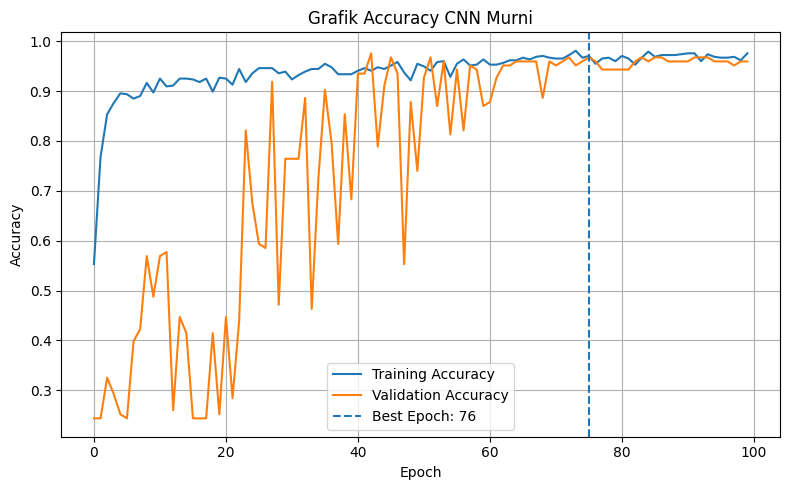

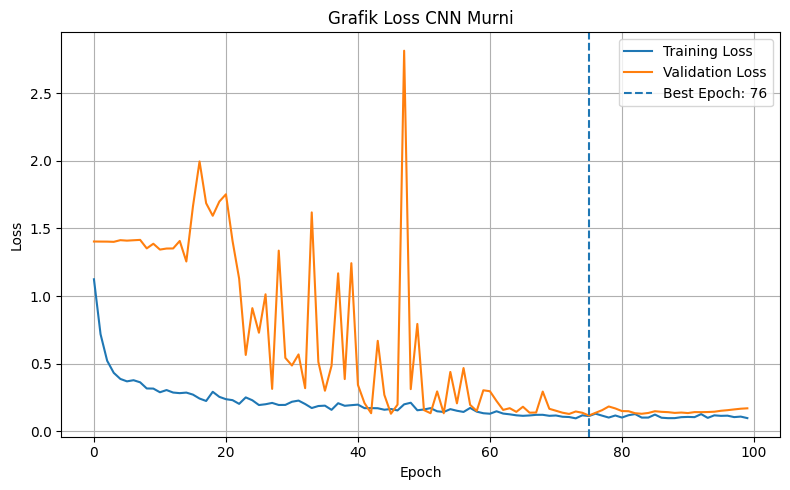

In [ ]:
plt.figure(figsize=(8, 5))
plt.plot(history_df["accuracy"], label="Training Accuracy")
plt.plot(history_df["val_accuracy"], label="Validation Accuracy")
plt.axvline(best_epoch - 1, linestyle="--", label=f"Best Epoch: {best_epoch}")
plt.title("Grafik Accuracy CNN Murni")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "grafik_accuracy.png"), dpi=200)
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(history_df["loss"], label="Training Loss")
plt.plot(history_df["val_loss"], label="Validation Loss")
plt.axvline(best_epoch - 1, linestyle="--", label=f"Best Epoch: {best_epoch}")
plt.title("Grafik Loss CNN Murni")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "grafik_loss.png"), dpi=200)
plt.show()

## 13. Evaluasi model terbaik pada validation set dan test set

Evaluasi akhir menggunakan model terbaik berdasarkan `val_loss`.

In [ ]:
best_model = tf.keras.models.load_model(best_model_path)

val_loss, val_acc = best_model.evaluate(val_ds, verbose=0)
test_loss, test_acc = best_model.evaluate(test_ds, verbose=0)

print("Validation Accuracy:", val_acc)
print("Validation Loss:", val_loss)
print("Test Accuracy:", test_acc)
print("Test Loss:", test_loss)

eval_df = pd.DataFrame({
    "Metrik": ["Validation Accuracy", "Validation Loss", "Test Accuracy", "Test Loss"],
    "Nilai": [val_acc, val_loss, test_acc, test_loss]
})

display(eval_df)
eval_df.to_csv(os.path.join(OUTPUT_DIR, "evaluasi_akhir.csv"), index=False)

Validation Accuracy: 0.9674796462059021
Validation Loss: 0.11637414246797562
Test Accuracy: 0.9512194991111755
Test Loss: 0.11695371568202972


,Metrik,Nilai
0,Validation Accuracy,0.967480
1,Validation Loss,0.116374
2,Test Accuracy,0.951219
3,Test Loss,0.116954


## 14. Confusion matrix dan classification report untuk test set

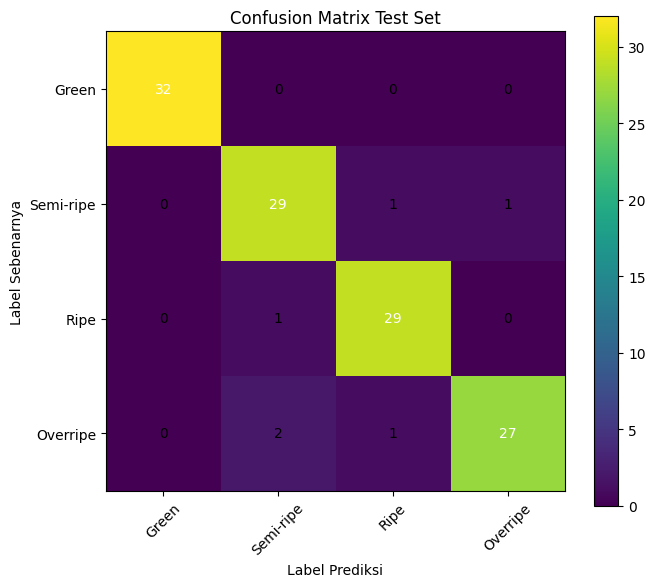

              precision    recall  f1-score   support

       Green       1.00      1.00      1.00        32
   Semi-ripe       0.91      0.94      0.92        31
        Ripe       0.94      0.97      0.95        30
    Overripe       0.96      0.90      0.93        30

    accuracy                           0.95       123
   macro avg       0.95      0.95      0.95       123
weighted avg       0.95      0.95      0.95       123



,precision,recall,f1-score,support
Green,1.000000,1.000000,1.000000,32.00000
Semi-ripe,0.906250,0.935484,0.920635,31.00000
Ripe,0.935484,0.966667,0.950820,30.00000
Overripe,0.964286,0.900000,0.931034,30.00000
accuracy,0.951220,0.951220,0.951220,0.95122
macro avg,0.951505,0.950538,0.950622,123.00000
weighted avg,0.951926,0.951220,0.951181,123.00000


In [ ]:
def get_predictions(model, dataset):
    y_true = []
    y_pred = []
    y_prob = []

    for images, labels in dataset:
        probs = model.predict(images, verbose=0)
        preds = np.argmax(probs, axis=1)

        y_true.extend(labels.numpy())
        y_pred.extend(preds)
        y_prob.extend(probs)

    return np.array(y_true), np.array(y_pred), np.array(y_prob)

y_true_test, y_pred_test, y_prob_test = get_predictions(best_model, test_ds)

cm = confusion_matrix(y_true_test, y_pred_test)

plt.figure(figsize=(7, 6))
plt.imshow(cm, interpolation="nearest")
plt.title("Confusion Matrix Test Set")
plt.colorbar()

tick_marks = np.arange(len(CLASS_NAMES))
plt.xticks(tick_marks, CLASS_NAMES, rotation=45)
plt.yticks(tick_marks, CLASS_NAMES)

threshold = cm.max() / 2
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(
            j, i, format(cm[i, j], "d"),
            ha="center", va="center",
            color="white" if cm[i, j] > threshold else "black"
        )

plt.ylabel("Label Sebenarnya")
plt.xlabel("Label Prediksi")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "confusion_matrix_test.png"), dpi=200)
plt.show()

report_dict = classification_report(
    y_true_test,
    y_pred_test,
    target_names=CLASS_NAMES,
    output_dict=True,
    zero_division=0
)

report_text = classification_report(
    y_true_test,
    y_pred_test,
    target_names=CLASS_NAMES,
    zero_division=0
)

print(report_text)

report_df = pd.DataFrame(report_dict).transpose()
display(report_df)

report_df.to_csv(os.path.join(OUTPUT_DIR, "classification_report_test.csv"))
with open(os.path.join(OUTPUT_DIR, "classification_report_test.txt"), "w", encoding="utf-8") as f:
    f.write(report_text)

## 15. Ringkasan otomatis untuk laporan

In [ ]:
final_summary = f'''
RINGKASAN HASIL CNN MURNI KLASIFIKASI KEMATANGAN PISANG

1. Dataset
- Folder dataset: {DATA_DIR}
- Jumlah gambar setelah pembersihan: {len(df_clean)}
- Jumlah kelas: {NUM_CLASSES}
- Kelas: {CLASS_NAMES}
- Split data: train {len(train_df)}, validation {len(val_df)}, test {len(test_df)}

2. Preprocessing
- Resize citra: {IMG_SIZE} x {IMG_SIZE} piksel
- Format warna: RGB 3 channel
- Normalisasi: Rescaling 1/255 di dalam model
- Pembersihan data: duplikat konflik label dibersihkan dari daftar training
- Augmentation: tidak digunakan pada model utama

3. Konfigurasi CNN
- Model: CNN murni/custom
- Conv2D kernel: 3 x 3
- Conv2D stride: 1
- Conv2D padding: same
- Aktivasi: ReLU
- Pooling: MaxPooling2D 2 x 2
- Vektor fitur: GlobalAveragePooling2D
- Output: Dense {NUM_CLASSES} neuron dengan softmax

4. Konfigurasi Training
- Epoch maksimal: {EPOCHS}
- Batch size: {BATCH_SIZE}
- Optimizer: {optimizer_name}
- Learning rate: {LEARNING_RATE}
- Weight decay: {WEIGHT_DECAY}
- Loss function: sparse_categorical_crossentropy
- Metric: accuracy
- Model terbaik dipilih berdasarkan validation loss terendah

5. Hasil Terbaik
- Epoch terbaik: {best_epoch}
- Training accuracy pada epoch terbaik: {best_train_acc:.4f}
- Training loss pada epoch terbaik: {best_train_loss:.4f}
- Validation accuracy pada epoch terbaik: {best_val_acc:.4f}
- Validation loss terbaik: {best_val_loss:.4f}

6. Evaluasi Akhir Model Terbaik
- Validation accuracy: {val_acc:.4f}
- Validation loss: {val_loss:.4f}
- Test accuracy: {test_acc:.4f}
- Test loss: {test_loss:.4f}

7. Interpretasi Singkat
Model CNN murni melakukan ekstraksi fitur citra menggunakan convolution layer.
Fitur yang dipelajari meliputi warna, tepi, tekstur, dan bercak pada kulit pisang.
CNN tidak menyimpan gambar sebagai database penuh, tetapi menyimpan hasil pembelajaran dalam bentuk bobot.
Bobot diperbarui selama training melalui backpropagation dan optimizer.
'''

print(final_summary)

with open(os.path.join(OUTPUT_DIR, "ringkasan_laporan_cnn.txt"), "w", encoding="utf-8") as f:
    f.write(final_summary)

with open(os.path.join(OUTPUT_DIR, "konfigurasi_model.json"), "w", encoding="utf-8") as f:
    json.dump(config_summary, f, indent=4)


RINGKASAN HASIL CNN MURNI KLASIFIKASI KEMATANGAN PISANG

1. Dataset
- Folder dataset: /content/drive/MyDrive/Tugas_Besar_Asli/banana_dataset
- Jumlah gambar setelah pembersihan: 819
- Jumlah kelas: 4
- Kelas: ['Green', 'Semi-ripe', 'Ripe', 'Overripe']
- Split data: train 573, validation 123, test 123

2. Preprocessing
- Resize citra: 128 x 128 piksel
- Format warna: RGB 3 channel
- Normalisasi: Rescaling 1/255 di dalam model
- Pembersihan data: duplikat konflik label dibersihkan dari daftar training
- Augmentation: tidak digunakan pada model utama

3. Konfigurasi CNN
- Model: CNN murni/custom
- Conv2D kernel: 3 x 3
- Conv2D stride: 1
- Conv2D padding: same
- Aktivasi: ReLU
- Pooling: MaxPooling2D 2 x 2
- Vektor fitur: GlobalAveragePooling2D
- Output: Dense 4 neuron dengan softmax

4. Konfigurasi Training
- Epoch maksimal: 100
- Batch size: 32
- Optimizer: AdamW
- Learning rate: 0.0008
- Weight decay: 0.0001
- Loss function: sparse_categorical_crossentropy
- Metric: accuracy
- Model te

## 16. Uji prediksi menggunakan foto pisang sendiri

Jalankan cell ini, lalu upload satu foto pisang.

In [ ]:
from google.colab import files

def predict_image(image_path, model=best_model):
    img = Image.open(image_path).convert("RGB")
    img_resized = img.resize((IMG_SIZE, IMG_SIZE))
    arr = np.array(img_resized).astype("float32")
    arr = np.expand_dims(arr, axis=0)

    probs = model.predict(arr, verbose=0)[0]
    pred_idx = int(np.argmax(probs))
    pred_class = CLASS_NAMES[pred_idx]
    confidence = float(probs[pred_idx])

    plt.figure(figsize=(5, 5))
    plt.imshow(img)
    plt.axis("off")
    plt.title(f"Prediksi: {pred_class} ({confidence*100:.2f}%)")
    plt.show()

    prob_df = pd.DataFrame({
        "Kelas": CLASS_NAMES,
        "Probabilitas": probs,
        "Persentase": probs * 100
    }).sort_values("Probabilitas", ascending=False)

    display(prob_df)

    return pred_class, confidence, prob_df

uploaded = files.upload()

for filename in uploaded.keys():
    print("File diuji:", filename)
    predict_image(filename)

NameError: name 'best_model' is not defined

## 18. Download semua hasil

Cell ini membuat file ZIP berisi model, grafik, laporan, confusion matrix, dan classification report.

In [ ]:
shutil.make_archive("/content/hasil_cnn_pisang", "zip", OUTPUT_DIR)

print("File ZIP hasil training selesai dibuat:")
print("/content/hasil_cnn_pisang.zip")

files.download("/content/hasil_cnn_pisang.zip")